<a href="https://colab.research.google.com/github/nayivealpala-bot/alpala_nayibe_montecarlo.doc/blob/main/yatzhee_montecarlo_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación del juego Yatzhee usando el método de Montecarlo

## Objetivo
Simular el juego Yatzhee para dos jugadores utilizando el método de Montecarlo, analizando los resultados obtenidos a partir de variables aleatorias con distribución uniforme.

# introducción
El método de Montecarlo es una técnica de simulación que permite modelar sistemas aleatorios mediante el uso de números pseudoaleatorios. En este caso, se aplica al juego Yatzhee, el cual se basa en lanzamientos de dados.

Cada dado sigue una distribución uniforme discreta, donde cada valor entre 1 y 6 tiene la misma probabilidad de ocurrencia.


Jugador 1 ganó: 452
Jugador 2 ganó: 488
Empates: 60
Promedio Jugador 1: 27.787
Promedio Jugador 2: 27.929
Varianza Jugador 1: 25.115631
Varianza Jugador 2: 31.515959


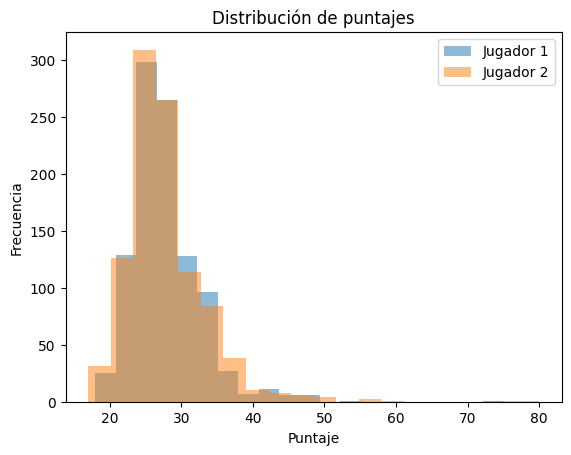

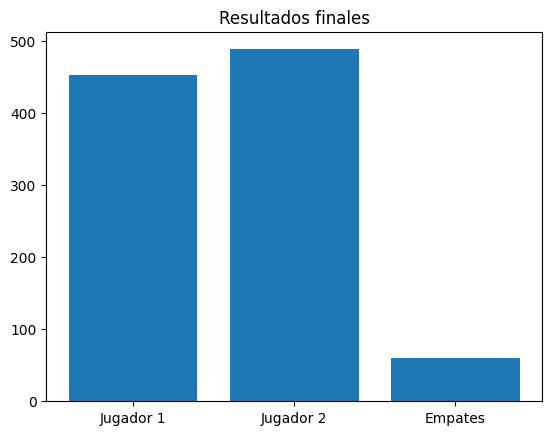


--- Ganador Final ---
¡El Jugador 2 es el GANADOR!


In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

# funcion para lanzar dados

def lanzar_dados(n=5):
    """
    Genera n valores aleatorios entre 1 y 6 (simulación de dados)
    """
    return np.random.randint(1, 7, size=n)

#evaluacion del puntaje

def evaluar_jugada(dados):
    """
    Evalúa la jugada según combinaciones
    """
    puntaje = np.sum(dados)
    valores, conteos = np.unique(dados, return_counts=True)

    if 5 in conteos:
        puntaje += 50  # Yahtzee
    elif 4 in conteos:
        puntaje += 20
    elif 3 in conteos:
        puntaje += 10
    elif 2 in conteos:
        puntaje += 5

    return puntaje

# simulacion de turno

def turno_jugador():
    """
    Simula un turno con hasta 3 lanzamientos
    Se queda con el mejor resultado
    """
    mejor_puntaje = 0

    for _ in range(3):
        dados = lanzar_dados()
        puntaje = evaluar_jugada(dados)

        if puntaje > mejor_puntaje:
            mejor_puntaje = puntaje

    return mejor_puntaje

# simulacion montecarlo

def simulacion_montecarlo(n_partidas=10000):
    resultados_j1 = []
    resultados_j2 = []

    victorias_j1 = 0
    victorias_j2 = 0
    empates = 0

    for _ in range(n_partidas):
        j1 = turno_jugador()
        j2 = turno_jugador()

        resultados_j1.append(j1)
        resultados_j2.append(j2)

        if j1 > j2:
            victorias_j1 += 1
        elif j2 > j1:
            victorias_j2 += 1
        else:
            empates += 1

    return resultados_j1, resultados_j2, victorias_j1, victorias_j2, empates

# ejecutar simulacion

resultados_j1, resultados_j2, v1, v2, emp = simulacion_montecarlo(1000)

print("Jugador 1 ganó:", v1)
print("Jugador 2 ganó:", v2)
print("Empates:", emp)

# analis estadistico

print("Promedio Jugador 1:", np.mean(resultados_j1))
print("Promedio Jugador 2:", np.mean(resultados_j2))

print("Varianza Jugador 1:", np.var(resultados_j1))
print("Varianza Jugador 2:", np.var(resultados_j2))

plt.hist(resultados_j1, bins=20, alpha=0.5, label="Jugador 1")
plt.hist(resultados_j2, bins=20, alpha=0.5, label="Jugador 2")
plt.legend()
plt.title("Distribución de puntajes")
plt.xlabel("Puntaje")
plt.ylabel("Frecuencia")
plt.show()

# grafico de victorias

plt.bar(["Jugador 1", "Jugador 2", "Empates"], [v1, v2, emp])
plt.title("Resultados finales")
plt.show()

# resultado final

print("\n--- Ganador Final ---")
if v1 > v2:
    print("¡El Jugador 1 es el GANADOR!")
elif v2 > v1:
    print("¡El Jugador 2 es el GANADOR!")
else:
    print("¡La partida terminó en EMPATE!")

## resultados

#Se observa que los puntajes siguen una distribución aproximadamente normal debido a la suma de variables aleatorias.

#Las diferencias entre jugadores se deben únicamente al azar, lo cual confirma la naturaleza estocástica del modelo.

#Al aumentar el número de simulaciones, los resultados tienden a estabilizarse.

# conclusiones

#El método de Montecarlo permite analizar sistemas aleatorios de forma eficiente.
#La simulación del juego Yatzhee refleja el comportamiento de variables aleatorias.
# La distribución uniforme es adecuada para modelar los dados.
# El modelo puede considerarse una cadena de Markov, ya que depende solo del estado actual.
#A mayor número de simulaciones, mayor precisión en los resultados.

